In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 1.EDA
- Kiểm tra chất lượng dữ liệu 
- Tìm hiểu 

In [2]:
df = pd.read_csv('Base.csv')

- Có bao nhiêu dữ liệu numerical và categorical

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [4]:
print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Number of numerical columns: 27
Number of categorical columns: 5


In [5]:
print("Có missing value không: ", df.isnull().values.any())

Có missing value không:  False


### 1.1 Phân tích dữ liệu dạng số

- Kiểm tra phân phối dữ liệu để xem có lỗi dữ liệu nào không

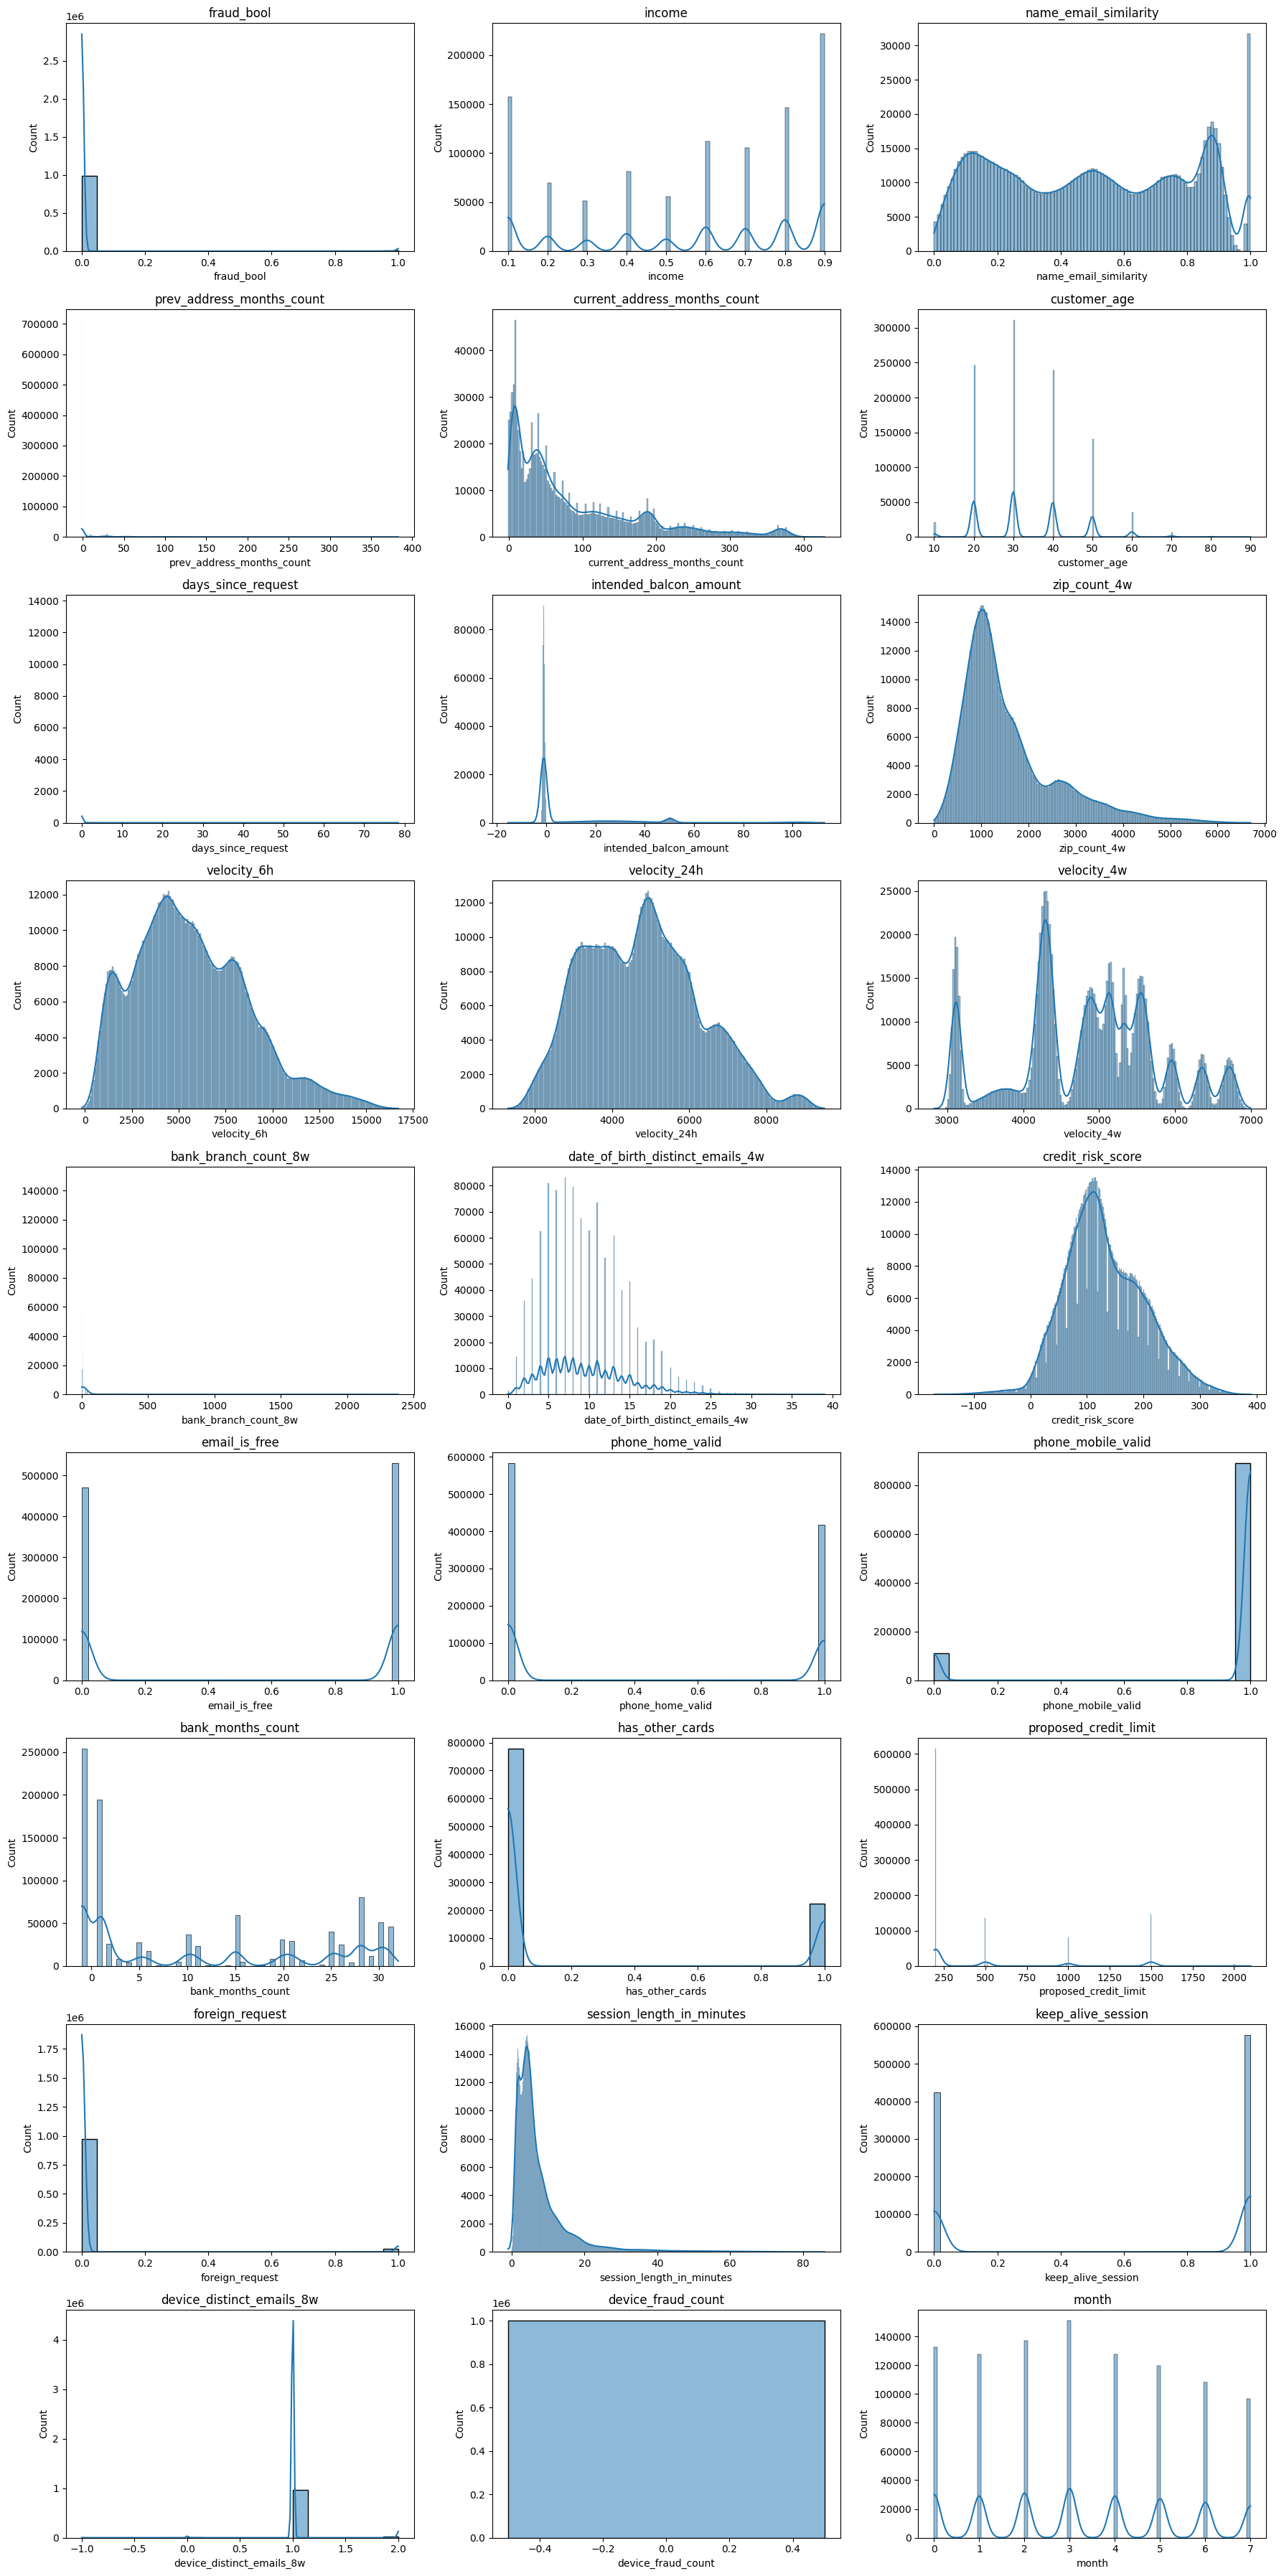

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns

n_cols = 3  # số plot mỗi hàng
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

# flatten để dễ truy cập
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Ẩn các subplot thừa
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Hầu hết data đều nằm trong range dữ liệu hơp lý ngoại trừ một số data ví dụ như device distinct emails 8w có một số dữ liệu -1 trong khi range data quy định là 0-3

In [7]:
df[(df['device_distinct_emails_8w'] < 0) | (df['device_distinct_emails_8w'] > 3)]['device_distinct_emails_8w'].value_counts()

device_distinct_emails_8w
-1    359
Name: count, dtype: int64

=> ý nghĩa của -1 trong bộ dataset: những giá trị -1 được quy định là missing value \
=> data có chứa nhiều null value

In [8]:
# Tính phần trăm missing value
ms_df = df.drop(columns=['credit_risk_score', 'intended_balcon_amount'], axis=1)
((ms_df == -1).sum() / len(ms_df) * 100).sort_values(ascending=False).head(10) 

prev_address_months_count       71.2920
bank_months_count               25.3635
current_address_months_count     0.4254
session_length_in_minutes        0.2015
device_distinct_emails_8w        0.0359
income                           0.0000
days_since_request               0.0000
payment_type                     0.0000
zip_count_4w                     0.0000
velocity_6h                      0.0000
dtype: float64

=> có năm cột có missing value: device_distinct_emails_8w, device_distinct_emails_4w, device_distinct_emails_2w, device_distinct_emails_1w, device_distinct_emails_3d

In [9]:
df['intended_balcon_amount'].min()

-15.530554840076814

### 1.2 Phân tích dữ liệu dạng categorical

In [10]:
len(cat_cols)

5

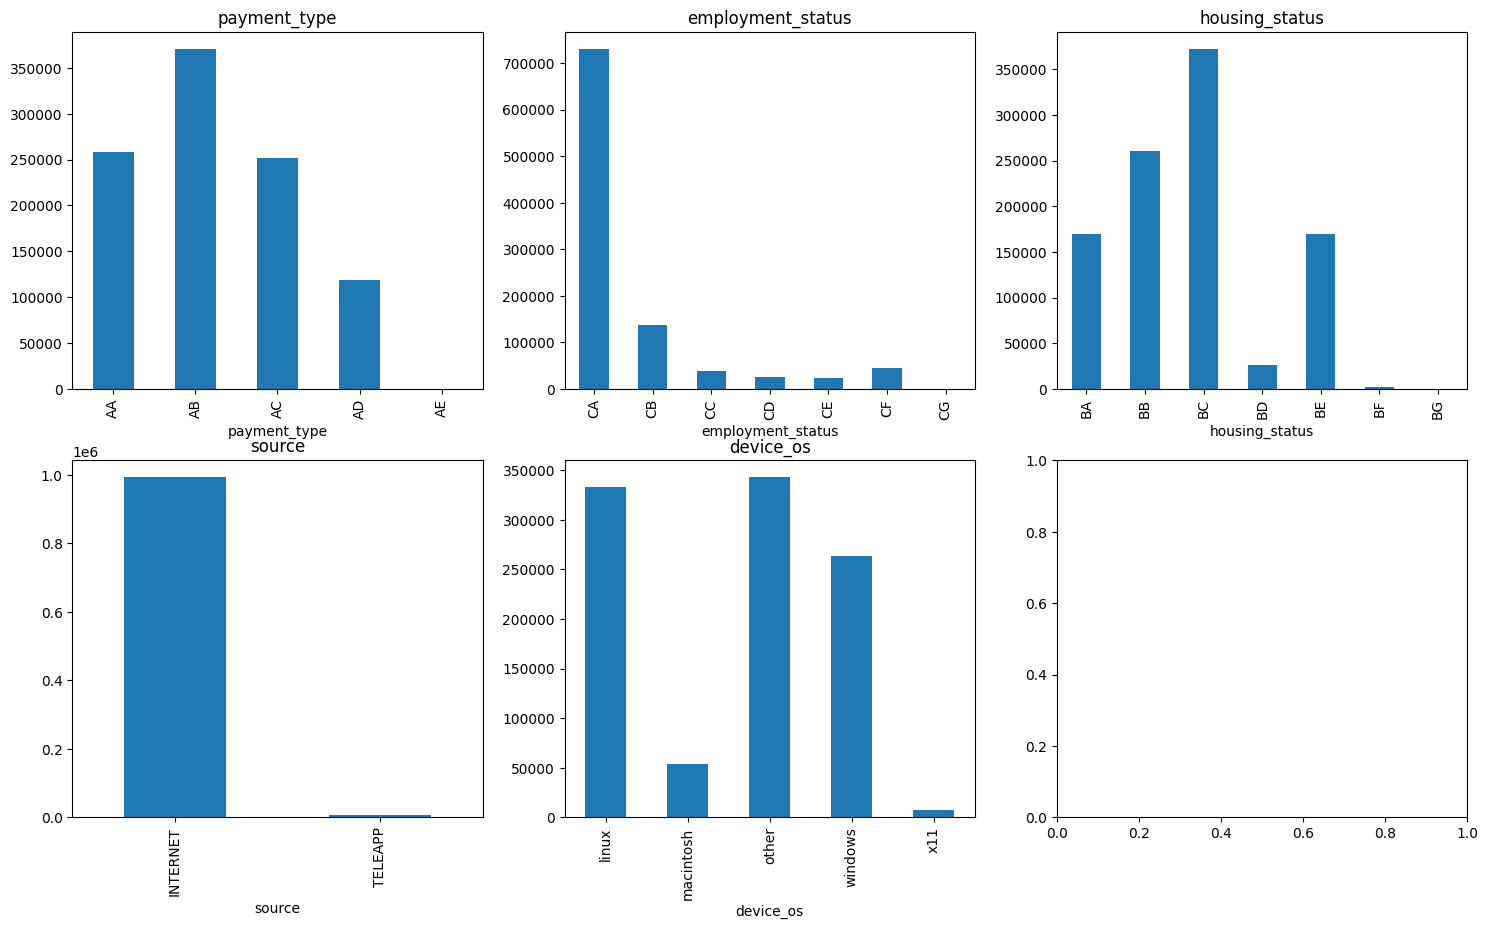

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(6 * 3, 5.1 * 2))

for i in range(len(cat_cols)):
    df[cat_cols[i]].value_counts().sort_index().plot(kind='bar', ax=axes[i // 3, i % 3], title=cat_cols[i])
# df['payment_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], title='Payment Type')

## 2. Build baseline model

Categorical: 5
Numerical: 26

LogisticRegression


/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Gini   : 0.7267
F1     : 0.0784
Recall : 0.7829


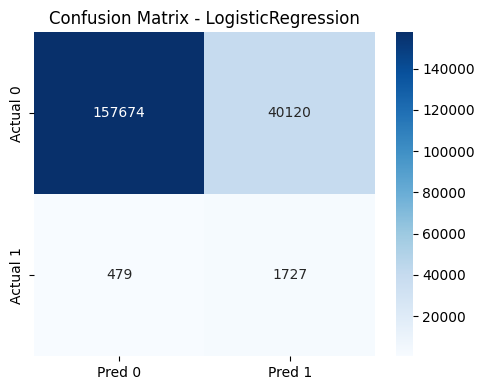


XGBoost
Gini   : 0.7866
F1     : 0.1061
Recall : 0.7525


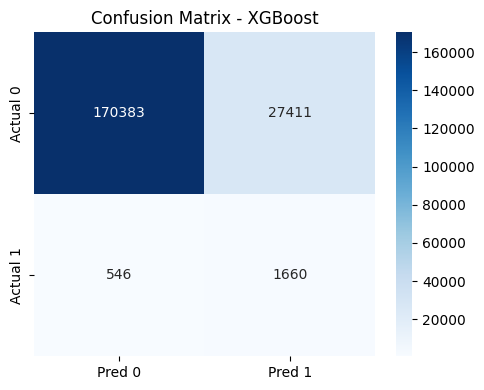


LightGBM
[LightGBM] [Info] Number of positive: 8823, number of negative: 791177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3213
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496160
[LightGBM] [Info] Start training from score -4.496160
Gini   : 0.7839
F1     : 0.0967
Recall : 0.7801


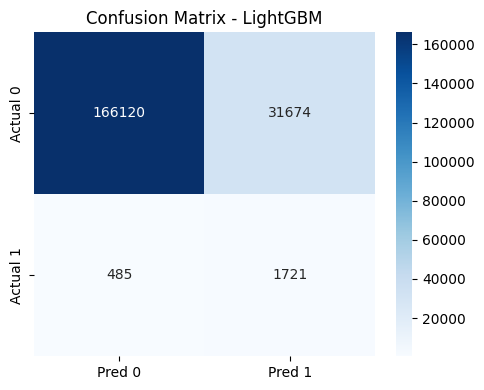


CatBoost
Gini   : 0.7955
F1     : 0.0950
Recall : 0.8060


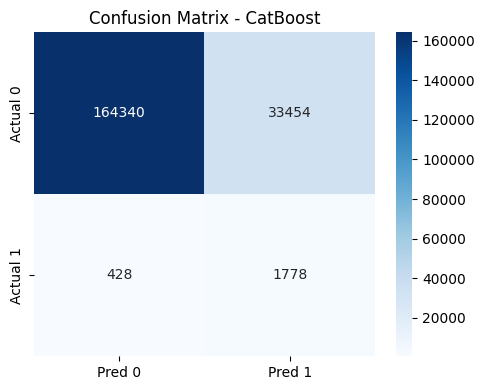


RESULTS
                Model      Gini        F1    Recall
3            CatBoost  0.795535  0.094984  0.805984
1             XGBoost  0.786593  0.106148  0.752493
2            LightGBM  0.783909  0.096683  0.780145
0  LogisticRegression  0.726675  0.078406  0.782865


In [12]:
# pip install pandas scikit-learn xgboost lightgbm catboost seaborn matplotlib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# LOAD DATA
# ====================================================
df = pd.read_csv("Base.csv")

TARGET = "fraud_bool"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# ====================================================
# SPLIT
# ====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ====================================================
# COLUMN TYPES
# ====================================================
cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

num_cols = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

# ====================================================
# IMBALANCE
# ====================================================
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# ====================================================
# PREPROCESS FOR LR + XGB
# ====================================================
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train_ohe = preprocessor.fit_transform(X_train)
X_test_ohe = preprocessor.transform(X_test)

# ====================================================
# PREPROCESS FOR LIGHTGBM + CATBOOST
# ====================================================

X_train_native = X_train.copy()
X_test_native = X_test.copy()

# numerical missing
for col in num_cols:
    median = X_train_native[col].median()

    X_train_native[col] = X_train_native[col].fillna(median)
    X_test_native[col] = X_test_native[col].fillna(median)

# categorical missing
for col in cat_cols:

    X_train_native[col] = (
        X_train_native[col]
        .fillna("MISSING")
        .astype("category")
    )

    X_test_native[col] = (
        X_test_native[col]
        .fillna("MISSING")
        .astype("category")
    )

# ====================================================
# MODELS
# ====================================================
models = {

    "LogisticRegression": (
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        X_train_ohe,
        X_test_ohe
    ),

    "XGBoost": (
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ),
        X_train_ohe,
        X_test_ohe
    ),

    "LightGBM": (
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ),
        X_train_native,
        X_test_native
    ),

    "CatBoost": (
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            verbose=0,
            random_state=42
        ),
        X_train_native,
        X_test_native
    )
}

# ====================================================
# TRAIN + EVALUATE
# ====================================================
results = []

for model_name, (model, Xtr, Xte) in models.items():

    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    if model_name == "CatBoost":

        model.fit(
            Xtr,
            y_train,
            cat_features=cat_cols
        )

    else:

        model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1

    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print(f"Gini   : {gini:.4f}")
    print(f"F1     : {f1:.4f}")
    print(f"Recall : {recall:.4f}")

    # ======================================
    # HEATMAP
    # ======================================
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model": model_name,
        "Gini": gini,
        "F1": f1,
        "Recall": recall
    })

# ====================================================
# SUMMARY
# ====================================================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Gini",
    ascending=False
)

print("\nRESULTS")
print(results_df)

## 3. Improve baseline

In [ ]:
from missdat import MC

/tmp/ipykernel_640727/1372051314.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: np.nan if x == -1 else x)
/tmp/ipykernel_640727/1372051314.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 9.  2. 30. ... 31.  1. 15.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, df.columns.difference(cols_to_skip)] = (
/tmp/ipykernel_640727/1372051314.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 25.  89.  14. ... 202.   3. 174.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, df.columns.difference(cols_to_skip)] = (
/tmp/ipykernel_640727/1372051314.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 1. 1. ..

In [1]:
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

pandas2ri.activate()

baylor = importr("BaylorEdPsych")

result = baylor.LittleMCAR(df)
print(result)

PackageNotInstalledError: The R package "BaylorEdPsych" is not installed.